### Baseline comparison
#### Last modified: 03/12/2026
#### Author: Landon Buskirk 

In [2]:
from collections import defaultdict
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
import json
import matplotlib.pyplot as plt
import scipy.stats as ss

In [3]:
raw_drug_data = pd.read_csv('../../data/baseline_analysis/drug_data/level3_control_expdata_lm.tsv', delimiter='\t')
raw_drug_data.set_index('rid', inplace=True)
landmark_genes = raw_drug_data.index
drug_samples = raw_drug_data.columns

In [11]:
split_drug = pd.DataFrame(columns=['exp', 'cell', 'time', 'x', 'end'])
for sam in drug_samples:
    parts = sam.split('_')
    split_drug.loc[len(split_drug.index)] = (
        parts[0],
        parts[1],
        parts[2],
        parts[3],
        '_'.join(parts[4:])
    )
split_drug = split_drug[split_drug['time'] == '24H'] # Remove 6H and 48H
split_drug.sort_values(by=['exp', 'cell', 'end'], inplace=True)
drug_data = raw_drug_data.loc[:,split_drug['exp']+'_'+split_drug['cell']+'_'+split_drug['time']+'_'+split_drug['x']+'_'+split_drug['end']]
split_drug.reset_index(drop=True, inplace=True)

def row_sample(rowi, include_x=False):
    columns = ['exp', 'cell', 'time']
    if include_x:
        columns.append('x')
    columns.append('end')
    
    return '_'.join(str(split_drug.loc[rowi, col]) for col in columns)

past = row_sample(0)
group = [row_sample(0, include_x=True)]
cols_to_concat = []
col_names = [past]

for i in range(1, len(split_drug.index)):
    cur = row_sample(i)
    if cur == past:
        group.append(row_sample(i, include_x=True))
    else:
        cols_to_concat.append(drug_data[group].mean(axis=1))
        group = [row_sample(i, include_x=True)]
        past = cur
        col_names.append(cur)
cols_to_concat.append(drug_data[group].mean(axis=1))

drug_data = pd.concat(cols_to_concat, axis=1)
drug_data.columns = col_names

# group drug samples by cell line -> drug_data_cell
cell_lines = list(set([x.split('_')[1] for x in drug_data.columns]))
drug_data_cell = pd.DataFrame(index=drug_data.index, columns=cell_lines)
for cell_line in cell_lines:
    cell_line_columns = [x for x in drug_data.columns if cell_line in x]
    drug_data_cell[cell_line] = drug_data[cell_line_columns].mean(axis=1)
drug_data = drug_data_cell

# https://github.com/ShawnLYU/Quantile_Normalize/blob/master/quantile_norm.py
def quantileNormalize(df_input):
    df = df_input.copy()
    #compute rank
    dic = {}
    for col in df:
        dic.update({col : sorted(df[col])})
    sorted_df = pd.DataFrame(dic)
    rank = sorted_df.mean(axis = 1).tolist()
    #sort
    for col in df:
        t = np.searchsorted(np.sort(df[col]), df[col])
        df[col] = [rank[i] for i in t]
    return df

drug_data = quantileNormalize(drug_data)

In [12]:
meta = pd.read_csv('../../data/RNAseq_data_forDE/clean_TB_sample_metadata_classification.tsv', sep='\t')
new_gsm_control = meta.loc[meta['CLASSIFICATION']=='healthy control without treatment', 'geo_accession'].values
dis_meta = pd.read_csv('../../data/metadata/Homo_sapiens.gene_info.tsv', delimiter='\t', header=[0], index_col=[0])
dis_meta = dis_meta[[element in landmark_genes for element in dis_meta['GeneID'].values]]
map = dis_meta.drop_duplicates(subset='Ensembl').set_index('Ensembl')['GeneID']
rnaseq_dis_data = pd.DataFrame({"GeneID": landmark_genes})
for file_name in os.listdir('../../data/baseline_analysis/RNAseq/'):
    dis_exp = pd.read_csv('../../data/baseline_analysis/RNAseq/'+file_name, delimiter='\t', low_memory=False, dtype={'GeneID': 'int32'})
    dis_exp.columns.values[0] = 'GeneID'
    dis_exp['GeneID'] = dis_exp['GeneID'].map(map)
    dis_exp = dis_exp.loc[np.isin(dis_exp['GeneID'], landmark_genes)] # subset for landmark genes
    dis_exp = dis_exp.loc[:, np.isin(dis_exp.columns.values, np.append(new_gsm_control, 'GeneID'))] # subset for control samples
    rnaseq_dis_data = rnaseq_dis_data.merge(dis_exp, how='left', on='GeneID')
rnaseq_dis_data = rnaseq_dis_data.set_index('GeneID').astype(float)
rnaseq_dis_data.columns.name = "Disease Samples"
rnaseq_dis_data = rnaseq_dis_data.T.drop_duplicates().T

rnaseq_tissue = meta.set_index('geo_accession').loc[rnaseq_dis_data.columns.values, 'TISSUE'].fillna('Missing')
rnaseq_cell = meta.set_index('geo_accession').loc[rnaseq_dis_data.columns.values, 'CELL'].fillna('Missing')

def qnorm_dis_data(dis_data, target_vec):
    dis_data_qn = dis_data.copy()
    target_vec = np.sort(np.array(target_vec))
    for col in dis_data_qn.columns:
        t = np.searchsorted(np.sort(dis_data[col]), dis_data[col])
        dis_data_qn.loc[:,col] = [target_vec[i] for i in t]
    return dis_data_qn.astype('float64')

rnaseq_dis_data.dropna(inplace=True)
rnaseq_genes = rnaseq_dis_data.index
rnaseq_dis_data_qn = qnorm_dis_data(rnaseq_dis_data, drug_data.iloc[:, 0].loc[rnaseq_genes])

In [ ]:
def get_correlations(drug_data, dis_sample, correlation_type='pearson'):
    """
    Calculate correlations between a disease sample and each drug sample.
    Expects no missing values in the drug data or disease sample.

    Parameters
    ----------
    drug_data : pandas.DataFrame
        Expression data of drug samples
    dis_sample : pandas.Series or pandas.DataFrame
        Expression data of disease sample(s)
    correlation_type : str or array_like, optional
        Type of correlation to calculate. Default is 'pearson'.
        Options are 'pearson', 'spearman', 'rbo', 'lasso', 'all'.

    Returns
    -------
    output : pandas.DataFrame
        Correlations between the disease sample and each drug sample. Each index 
        is a drug sample and each column is a correlation type.
    """

    correlation_type = np.array(correlation_type)
    if 'all' in correlation_type :
        correlation_type = np.array(['pearson', 'spearman', 'rbo', 'lasso'])


    if isinstance(dis_sample, pd.DataFrame):
        # array_3d[dis_sample, drug_sample, correlation_type]
        array_3d = np.array([
            get_correlations(drug_data, dis_sample[col], correlation_type).values
            for col in dis_sample.columns
        ], dtype=float)
        return array_3d

    else:
        output = pd.DataFrame(index=drug_data.columns, columns=correlation_type)

        if 'pearson' in correlation_type:
            for drug_sample in drug_data.columns:
                output.loc[drug_sample, 'pearson'] = \
                    ss.pearsonr(dis_sample, drug_data[drug_sample])[0]
        if 'spearman' in correlation_type:
            for drug_sample in drug_data.columns:
                output.loc[drug_sample, 'spearman'] = \
                    ss.spearmanr(dis_sample, drug_data[drug_sample])[0]
        if 'rbo' in correlation_type:
            sorted_dis_geneids = dis_sample.sort_values(ascending=False).index.values
            drug_data = drug_data[np.isin(drug_data.index, sorted_dis_geneids)]
            for drug_sample in drug_data.columns:
                sorted_drug_geneids = drug_data[drug_sample].sort_values(ascending=False).index.values
                output.loc[drug_sample, 'rbo'] = \
                    rbo_rank(sorted_dis_geneids, sorted_drug_geneids).rbo(p=.99) 
        if 'lasso' in correlation_type:
            lasso = Lasso(alpha=.1, max_iter=10000)
            lasso.fit(drug_data.values, dis_sample.values)
            output.loc[:, 'lasso'] = lasso.coef_
     
        return output


types = np.array(['pearson'])

def save_ranks(drug_data, dis_data, filename):
    # 3D array: [drug, dis, corr]
    arr_3d = get_correlations(drug_data, dis_data, 
                                correlation_type=types).astype('float32')
    
    # List of dataframes: [drug, dis]
    corr_matrices = [pd.DataFrame(arr_3d[:,:,i].T, index=drug_data.columns, 
                                columns=dis_data.columns) 
                    for i in range(arr_3d.shape[2])]
    
    for i, mat in enumerate(corr_matrices):
        mat.to_csv(f'{filename}{types[i][0]}.csv')

drug_data_rna_subset = drug_data_cell.loc[rnaseq_genes]

save_ranks(drug_data_rna_subset, rnaseq_dis_data_qn, f'rna_ranks_')

In [15]:
drug_tissue_groups

defaultdict(list,
            {'skin': ['A375',
              'A375.311',
              'MCH58',
              'SKMEL1',
              'SKMEL28',
              'FIBRNPC'],
             'lung': ['A549',
              'A549.311',
              'CORL23',
              'DV90',
              'H1299',
              'HCC15',
              'HCC515',
              'NCIH1694',
              'NCIH1836',
              'NCIH2073',
              'NCIH596',
              'SKLU1',
              'T3M10'],
             'bone': ['A673', 'HS27A', 'U2OS', 'CD34'],
             'stomach': ['AGS'],
             'breast': ['BT20',
              'HME1',
              'HS578T',
              'MCF10A',
              'MCF7',
              'MCF7.101',
              'MCF7.311',
              'MDAMB231',
              'SKBR3'],
             'large intestine': ['CL34',
              'HCT116',
              'HELA',
              'HELA.311',
              'HT115',
              'HT29',
              'HT29.311',
       

In [16]:
cell_line_counts

{'FIBRNPC': 100,
 'CD34': 43,
 'HEK293T': 62,
 'NEU': 277,
 'THP1': 243,
 'HA1E': 1135,
 'HUH7': 184,
 'A375': 2264,
 'PC3': 4060,
 'SKBR3': 265,
 'NKDBA': 88,
 'VCAP': 5071,
 'HT29': 2059,
 'U937': 78,
 'SKB': 480,
 'BT20': 273,
 'NPC': 561,
 'HS578T': 232,
 'NOMO1': 274,
 'HCC515': 957,
 'MCF10A': 196,
 'MDAMB231': 251,
 'PHH': 325,
 'ASC': 244,
 'HEPG2': 780,
 'U266': 56,
 'A549': 2847,
 'JURKAT': 56,
 'HL60': 86,
 'MCF7': 4389}

In [23]:
cell_line_tissues

{'A375': 'skin',
 'A375.311': 'skin',
 'A549': 'lung',
 'A549.311': 'lung',
 'A673': 'bone',
 'AGS': 'stomach',
 'BT20': 'breast',
 'CL34': 'large intestine',
 'CORL23': 'lung',
 'COV644': 'ovary',
 'DV90': 'lung',
 'EFO27': 'ovary',
 'H1299': 'lung',
 'HA1E': 'kidney',
 'HA1E.101': 'kidney',
 'HA1E.311': 'kidney',
 'HCC15': 'lung',
 'HCC515': 'lung',
 'HCT116': 'large intestine',
 'HEC108': 'endometrium',
 'HEK293T': 'kidney',
 'HEKTE': 'kidney',
 'HELA': 'large intestine',
 'HELA.311': 'large intestine',
 'HEPG2': 'liver',
 'HL60': 'haematopoietic and lymphoid tissue',
 'HME1': 'breast',
 'HS27A': 'bone',
 'HS578T': 'breast',
 'HT115': 'large intestine',
 'HT29': 'large intestine',
 'HT29.311': 'large intestine',
 'HUH7': 'liver',
 'HUVEC': 'vascular system',
 'JHUEM2': 'endometrium',
 'JURKAT': 'haematopoietic and lymphoid tissue',
 'LNCAP': 'prostate',
 'LOVO': 'large intestine',
 'MCF10A': 'breast',
 'MCF7': 'breast',
 'MCF7.101': 'breast',
 'MCF7.311': 'breast',
 'MCH58': 'skin',

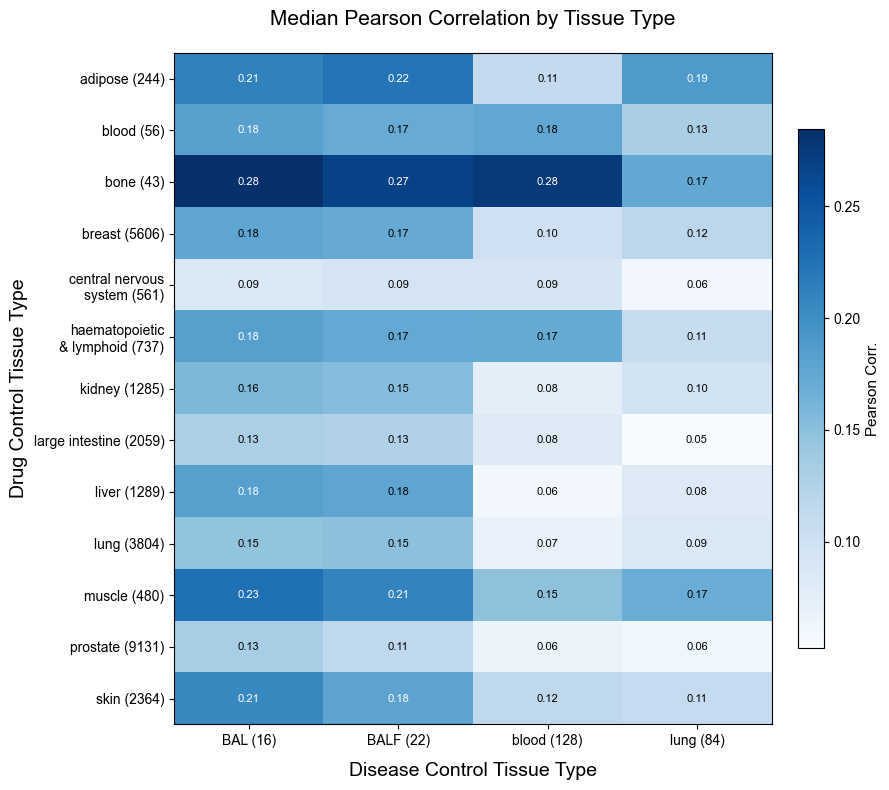

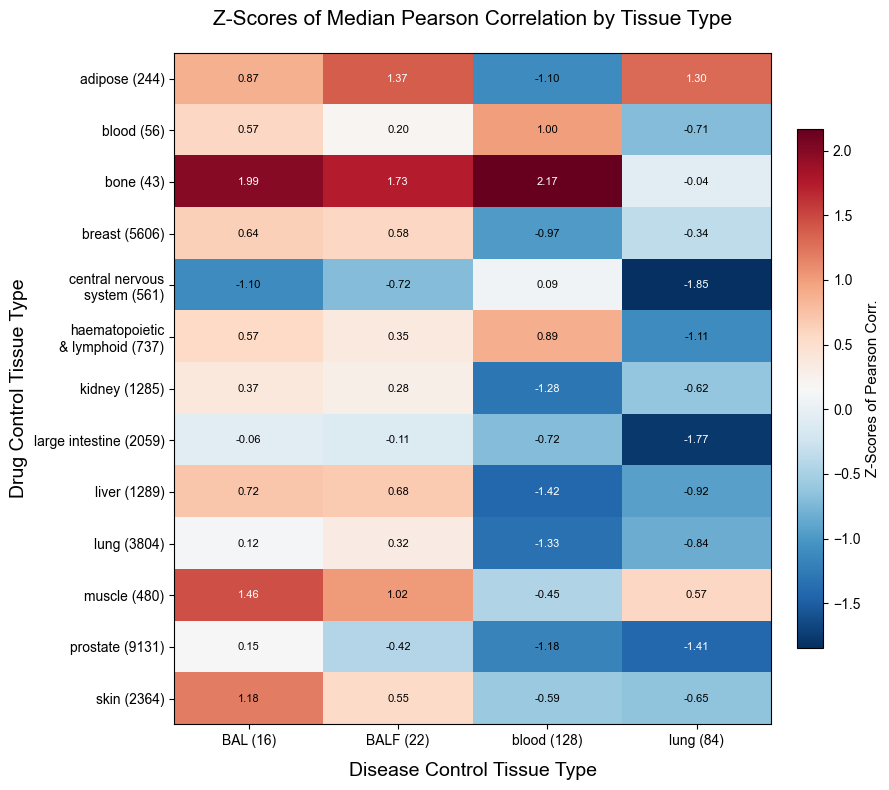

In [27]:
p = pd.read_csv('rna_ranks_p.csv', index_col=0)

cell_lines = drug_data.columns
# Number of columns per cell line
cell_line_counts = {
    cell_line: sum(cell_line in col for col in raw_drug_data.columns)
    for cell_line in cell_lines
}

# read in 'cell_line_to_tissue.json'
# with open('cell_line_to_tissue.json', 'r') as f:
#     cell_line_tissues = json.load(f)

cell_line_tissues = pd.read_csv('GSE92742_Broad_LINCS_cell_info.txt', sep='\t').set_index('cell_id')['primary_site'].to_dict()

cell_line_tissues = {
    k: v for k, v in cell_line_tissues.items()
    if k in cell_line_counts
}


# Group: tissue → list of cell lines/samples
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    drug_tissue_groups[tissue].append(cl)

# disease tissues
disease_tissue_groups = defaultdict(list)
tiss = rnaseq_tissue.value_counts()[rnaseq_tissue.value_counts() > 10].index
for sample, tissue in rnaseq_tissue[rnaseq_tissue.isin(tiss)].items():
    disease_tissue_groups[tissue].append(sample)

# Build tissue x tissue median correlation matrix
drug_tissues = sorted(drug_tissue_groups.keys())
disease_tissues = sorted(disease_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=disease_tissues, dtype=float)

for dt in drug_tissues:
    for ds in disease_tissues:
        cell_lines = drug_tissue_groups[dt]
        samples = disease_tissue_groups[ds]
        submatrix = p.loc[p.index.intersection(cell_lines), p.columns.intersection(samples)]
        if not submatrix.empty:
            tissue_matrix.loc[dt, ds] = np.median(submatrix.values)

matrix = tissue_matrix.values.astype(float)[1:, :]

def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

mpl.rcParams['font.family'] = 'Arial'

# Shortened names
dis_tis_name_map = {
    'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
    'PBMCs isolated from Healthy individuals' : 'PBMC',
    'Purified cord blood CD34+ cells': 'cord blood CD34+',
    'monocyte-derived macrophages': 'macrophages',
}
drug_tis_name_map = {
    'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid',
    'central nervous system': 'central nervous\nsystem',
}

# --- Function to add counts to tick labels ---
def add_counts_to_labels(tissues, groups, name_map):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = len(groups[t])
        labels.append(f"{pretty_name} ({count})")
    return labels

# tissue -> total number of drug samples (columns) across its cell lines
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts[cl] for cl in cl_list)
    for tissue, cl_list in drug_tissue_groups.items()
}

def add_counts_to_labels_with_samples(tissues, name_map, sample_counts_dict):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = sample_counts_dict.get(t, 0)
        labels.append(f"{pretty_name} ({count})")
    return labels

# Use this for drug tissue labels
ylabels = add_counts_to_labels_with_samples(
    drug_tissues[1:], drug_tis_name_map, drug_tissue_sample_counts
)

# Labels with counts
xlabels = add_counts_to_labels(disease_tissues, disease_tissue_groups, dis_tis_name_map)
# ylabels = add_counts_to_labels(drug_tissues[1:], drug_tissue_groups, drug_tis_name_map)

# --- Function to plot heatmap and add dict key ---
def plot_heatmap(matrix, xlabels, ylabels, title, cbar_label, cmap='Blues', annotate=True, center_zero=False):
    fig, ax = plt.subplots(figsize=(9, 8))
    cax = ax.imshow(matrix, cmap=cmap, aspect='auto')
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if center_zero:
        absmax = np.nanmax(np.abs(matrix)) - 0.5
        vmin, vmax = -absmax, absmax
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    if center_zero:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if abs(val) < (absmax * 0.75) else 'white')
                    else:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=0, fontsize=10)
    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=10)

    ax.set_xlabel('Disease Control Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Control Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # Add the drug tissue → cell line key below the figure 
    # drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])

    # plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
    #             wrap=False, ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Plot both heatmaps ---
plot_heatmap(matrix, xlabels, ylabels,
             'Median Pearson Correlation by Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, xlabels, ylabels,
             'Z-Scores of Median Pearson Correlation by Tissue Type',
             'Z-Scores of Pearson Corr.', cmap='RdBu_r', center_zero=True)


## Drug vs. Drug Matrix

In [ ]:
drug_data = pd.read_csv('../../data/baseline_analysis/drug_data/level3_control_expdata_lm.tsv', delimiter='\t')
drug_data.set_index('rid', inplace=True)
landmark_genes = drug_data.index
drug_samples = drug_data.columns

#'stouffer':
# Group drug samples by cell line with Stouffer-like weighting
cell_lines = list(set([x.split('_')[1] for x in drug_data.columns]))
drug_data_cell = pd.DataFrame(index=drug_data.index, columns=cell_lines)
for cell_line in cell_lines:
    cell_line_columns = [x for x in drug_data.columns if cell_line in x]
    weights = []
    for col in cell_line_columns:
        correlations = []
        for col2 in cell_line_columns:
            if col != col2:
                corr = np.corrcoef(drug_data[col], drug_data[col2])[0,1]
                correlations.append(corr)
        avg_corr = np.mean(correlations)
        avg_corr = 0 if avg_corr < 0.05 else avg_corr
        weights.append(avg_corr)
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    drug_data_cell[cell_line] = np.sum(drug_data[cell_line_columns].values * weights, axis=1)

correlation_type = np.array(['pearson'])  # or ['pearson','spearman',...]
all_corrs = {}

for corr_type in correlation_type:
    corr_df = pd.DataFrame(index=drug_data_cell.columns, columns=drug_data_cell.columns, dtype=float)
    for col in drug_data_cell.columns:
        # get_correlations expects dis_sample as a Series
        result = get_correlations(drug_data_cell, drug_data_cell[col], correlation_type=[corr_type])
        # result is a 1-column dataframe with index = drug_data.columns
        corr_df.loc[:, col] = result[corr_type]
    all_corrs[corr_type] = corr_df

for corr_type, mat in all_corrs.items():
    mat.to_csv(f'drug_pearson.csv')

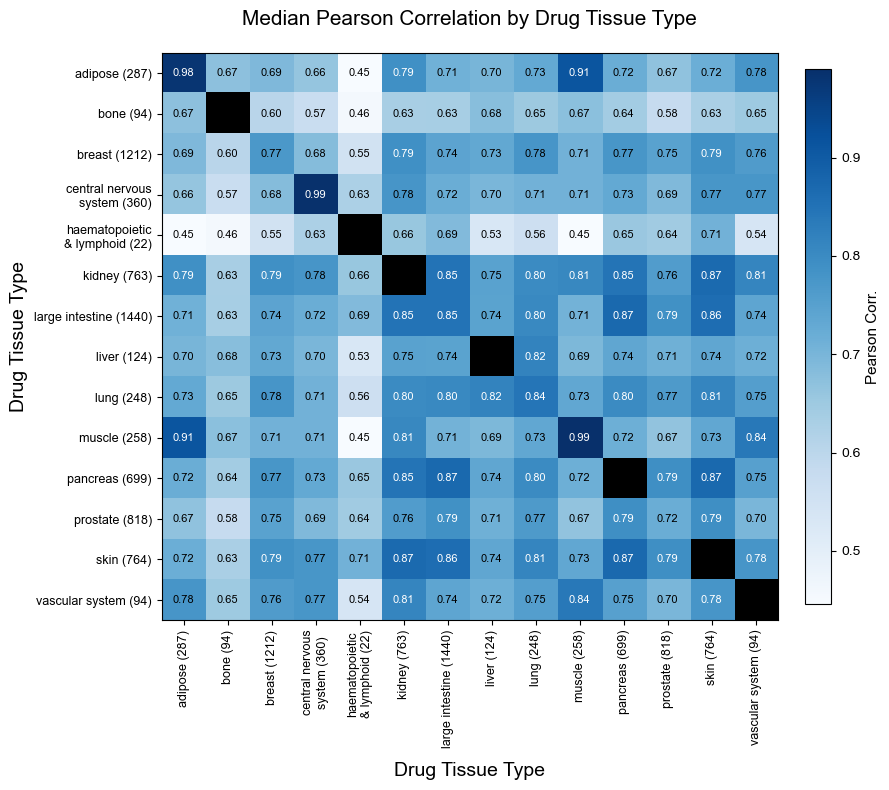

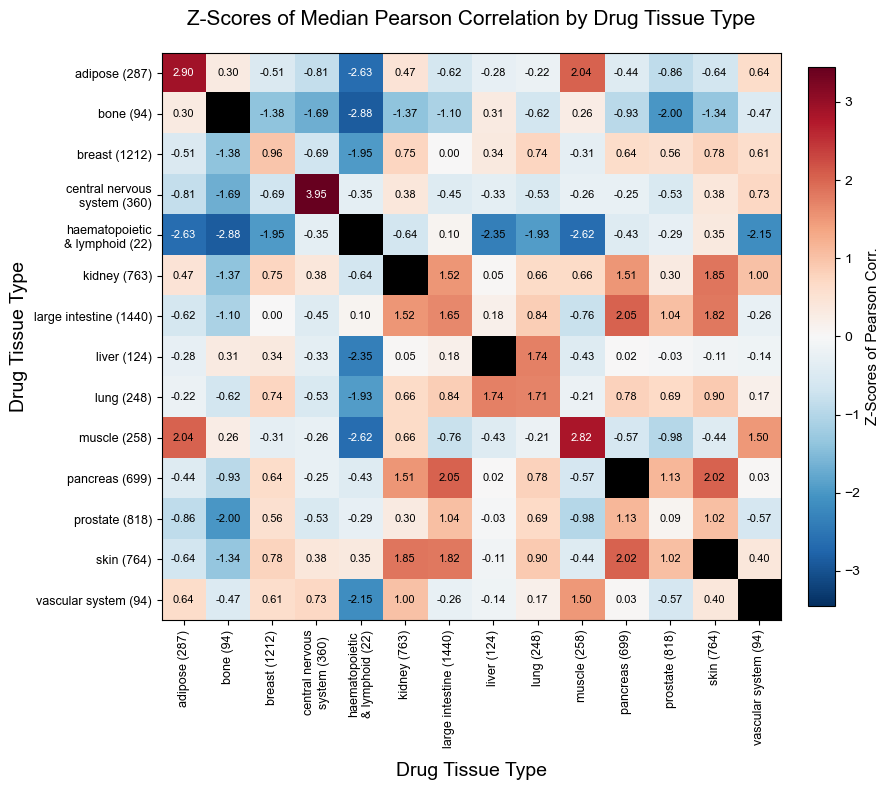

In [108]:
# --- Build tissue × tissue max correlation matrix ---
drug_tissues = sorted(drug_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=drug_tissues, dtype=float)

for t1 in drug_tissues:
    for t2 in drug_tissues:
        cell_lines_1 = drug_tissue_groups[t1]
        cell_lines_2 = drug_tissue_groups[t2]

        submatrix = p.loc[
            p.index.intersection(cell_lines_1),
            p.columns.intersection(cell_lines_2)
        ].copy()

        if t1 == t2:
            # Mask out same-cell-line comparisons (diagonal)
            np.fill_diagonal(submatrix.values, np.nan)

        # If there are any remaining values, take max; else NaN
        if np.isfinite(submatrix.values).any():
            tissue_matrix.loc[t1, t2] = np.nanmedian(submatrix.values)
        else:
            tissue_matrix.loc[t1, t2] = np.nan

matrix = tissue_matrix.values.astype(float)[1:, 1:]

# --- Z-score normalization ---
def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

# --- Updated heatmap function with optional center 0 ---
def plot_heatmap(matrix, labels, title, cbar_label, cmap='Blues', annotate=True, center_zero=False):
    fig, ax = plt.subplots(figsize=(9, 8))

    if center_zero:
        absmax = np.nanmax(np.abs(matrix)) - 0.5
        vmin, vmax = -absmax, absmax
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='black')

    cax = ax.imshow(matrix, cmap=cmap_obj, aspect='auto', vmin=vmin, vmax=vmax)
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    if center_zero:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if abs(val) < (absmax * 0.75) else 'white')
                    else:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)

    ax.set_xlabel('Drug Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])
    # plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
    #             wrap=False, ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()


# --- Plot both heatmaps ---
plot_heatmap(matrix, labels,
             'Median Pearson Correlation by Drug Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, labels,
             'Z-Scores of Median Pearson Correlation by Drug Tissue Type',
             'Z-Scores of Pearson Corr.', cmap='RdBu_r', center_zero=True)
